In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Optimize JupyterLab display aesthetics

In [2]:
pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(12)
pl.Config.set_float_precision(4)

polars.config.Config

# 2. Open an un-materialized high-performance file stream pointer

In [3]:
# Starts directly in your current notebook directory
data_dir = Path.cwd() / "data/1_rawdata" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data/1_rawdata"

# Combine paths cleanly
csv_path = data_dir / "smart_meters.csv"

df = pl.read_csv(
    csv_path,
    has_header=True,
    separator=",",
    
    # Performance & Memory Tuning
    infer_schema_length=10000,  # Look at 10k rows to accurately detect data types
    n_rows=None,                # Set to an integer (e.g., 10000) to test a small subset first
    
    # Data Cleaning & Safety
    ignore_errors=False,        # Set to True to drop malformed/corrupted rows instead of crashing
    try_parse_dates=True        # Automatically convert date/time columns to Polars Date/Datetime types
)

# 3. Data Profiling

In [4]:
# 3.1. Smart Meters Schema
print("--- Smart Meters -  Schema Preview ---")
print(df.schema)

--- Smart Meters -  Schema Preview ---
Schema([('Meter ID', String), ('Transformer ID', String), ('Consumer ID', String), ('HES ID', String), ('Install Date', Date), ('Reading Date', Date), ('Comm Protocol', String)])


In [5]:
# 3,2. Smart Meters -  Data Shape & Describe Preview
print("--- Smart meters -  Shape and Describe Preview ---")
print(df.glimpse())

--- Smart meters -  Shape and Describe Preview ---
Rows: 15250000
Columns: 7
$ Meter ID        <str> 'MTR-00000001', 'MTR-00000002', 'MTR-00000003', 'MTR-00000004', 'MTR-00000005', 'MTR-00000006', 'MTR-00000007', 'MTR-00000008', 'MTR-00000009', 'MTR-00000010'
$ Transformer ID  <str> 'DXF-081750', 'DXF-144459', 'DXF-084721', 'DXF-022577', 'DXF-133546', 'DXF-149830', 'DXF-027007', 'DXF-146067', 'DXF-131919', 'DXF-133996'
$ Consumer ID     <str> 'CON-04550726', 'CON-06186427', 'CON-08057045', 'CON-00674983', 'CON-01724178', 'CON-03787714', 'CON-05365136', 'CON-13276499', 'CON-06787287', 'CON-06572590'
$ HES ID          <str> 'HES-026', 'HES-061', 'HES-060', 'HES-175', 'HES-052', 'HES-083', 'HES-130', 'HES-181', 'HES-163', 'HES-083'
$ Install Date   <date> 2019-03-12, 2015-07-30, 2017-05-21, 2019-02-25, 2023-08-17, 2018-02-18, 2018-03-05, 2019-04-04, 2015-05-29, 2023-06-10
$ Reading Date   <date> 2026-08-08, 2026-07-17, 2026-08-22, 2026-08-03, 2026-07-28, 2026-08-03, 2026-08-23, 2026-07-28

# 4. Count missing values in parallel across millions of records

In [6]:
# Create a comprehensive audit summary
total_rows = df.height
null_counts = df.select(pl.all().is_null().sum())
null_pcts = df.select((pl.all().is_null().sum() / total_rows * 100).round(2))

# Reshape them vertically using unpivot
counts_vertical = null_counts.unpivot(variable_name="Column", value_name="Null Count")
pcts_vertical = null_pcts.unpivot(variable_name="Column", value_name="Null Percentage (%)")

# Join them together by the Column name
audit_df = counts_vertical.join(pcts_vertical, on="Column").sort("Null Count", descending=True)

print(audit_df)

shape: (7, 3)
┌────────────────┬────────────┬─────────────────────┐
│ Column         ┆ Null Count ┆ Null Percentage (%) │
│ ---            ┆ ---        ┆ ---                 │
│ str            ┆ u32        ┆ f64                 │
╞════════════════╪════════════╪═════════════════════╡
│ Meter ID       ┆ 0          ┆ 0.0000              │
│ Transformer ID ┆ 0          ┆ 0.0000              │
│ Consumer ID    ┆ 0          ┆ 0.0000              │
│ HES ID         ┆ 0          ┆ 0.0000              │
│ Install Date   ┆ 0          ┆ 0.0000              │
│ Reading Date   ┆ 0          ┆ 0.0000              │
│ Comm Protocol  ┆ 0          ┆ 0.0000              │
└────────────────┴────────────┴─────────────────────┘


# 5 Plotting chart about metrics generated from the exploration.

In [7]:
# 5.1.. Calculate the metrics
total_rows = df.height

# Count actual Polars 'null' values across all columns
total_nulls = df.select(pl.all().is_null().sum()).sum_horizontal().item()


# Count empty strings ("") which often represent missing text data
string_cols = [col for col, dtype in df.schema.items() if dtype == pl.String]
if string_cols:
    total_empty_strings = df.select(pl.col(string_cols).eq("").sum()).sum_horizontal().item()
else:
    total_empty_strings = 0

In [8]:
# 5.2.. Setup data for plotting
metrics = ['Total Rows', 'Null Values', 'Missing (Empty Strings)']
counts = [total_rows, total_nulls, total_empty_strings]
colors = ['#1f77b4', '#ff7f0e', '#d62728'] # Blue, Orange, Red

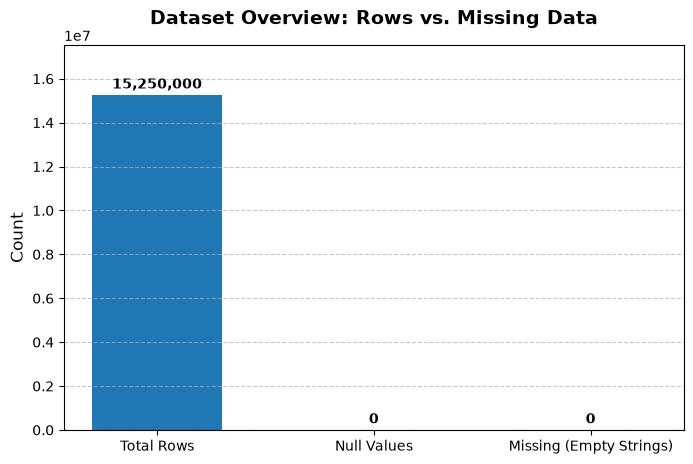

In [9]:
# 5.3. Generate the plot
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, counts, color=colors, width=0.6)

# Add exact value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (total_rows * 0.01), 
             f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Dataset Overview: Rows vs. Missing Data', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-limit to give space for labels
plt.ylim(0, max(counts) * 1.15)

plt.show()